In [13]:
# Cell 1 — Imports + load Q
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pyswip import Prolog

from run_race import run_one_race_hybrid

with open("q_table.pkl", "rb") as f:
    Q = pickle.load(f)

print("Loaded Q entries:", len(Q))

Loaded Q entries: 2682


In [14]:
# Cell 2 — Experiment runner (returns a DataFrame)
def run_experiment(Q, drivers, scenario, runs_per_driver=100, seed0=1000):
    """
    Runs repeated simulations and returns a DataFrame with one row per race.

    Columns include:
      driver, run_idx, seed, utility, dsq, pits_max, pits_min, mm_consults, mm_overrides, steps
      plus all scenario fields expanded (laps, start_weather, regime, depth, setup, track)
    """
    rows = []
    for d in drivers:
        for i in range(runs_per_driver):
            seed = seed0 + i
            result = run_one_race_hybrid(
                Q=Q,
                driver=d,
                seed=seed,
                verbose=False,
                **scenario,
            )

            u = result.get("terminal_value", None)
            dsq = 1 if (u is not None and abs(u) >= 900) else 0

            rows.append({
                "driver": d,
                "run_idx": i,
                "seed": seed,
                "utility": u,
                "dsq": dsq,
                "pits_max": result.get("pits_max", 0),
                "pits_min": result.get("pits_min", 0),
                "mm_consults": result.get("mm_consults", 0),
                "mm_overrides": result.get("mm_overrides", 0),
                "steps": result.get("steps", None),
                # scenario fields
                "laps": scenario.get("laps"),
                "start_weather": scenario.get("start_weather"),
                "regime": scenario.get("regime"),
                "depth": scenario.get("depth"),
                "setup": str(scenario.get("setup")),
                "track": scenario.get("track"),
            })
    return pd.DataFrame(rows)

In [15]:
# Cell 3 — Run your main scenario
drivers = ["max", "lewis", "lando", "charles", "george"]

scenario = dict(
    laps=55,
    start_weather="drizzle",
    regime="unstable",
    depth=4,
    setup=(3, 3, "high"),
    track="interlagos",
)

runs_per_driver = 100

df = run_experiment(Q, drivers, scenario, runs_per_driver=runs_per_driver, seed0=1000)
df.head()

,driver,run_idx,seed,utility,dsq,pits_max,pits_min,mm_consults,mm_overrides,steps,laps,start_weather,regime,depth,setup,track
0,max,0,1000,-151.9240,0,1,1,23,1,27,55,drizzle,unstable,4,"(3, 3, 'high')",interlagos
1,max,1,1001,-159.2080,0,2,2,25,2,27,55,drizzle,unstable,4,"(3, 3, 'high')",interlagos
2,max,2,1002,-86.3624,0,2,1,20,2,27,55,drizzle,unstable,4,"(3, 3, 'high')",interlagos
3,max,3,1003,-148.0396,0,2,2,21,2,27,55,drizzle,unstable,4,"(3, 3, 'high')",interlagos
4,max,4,1004,-138.7464,0,2,3,23,2,27,55,drizzle,unstable,4,"(3, 3, 'high')",interlagos


In [16]:
# Cell 4 — Summary table (like your printout, but as a table)
summary = (
    df.groupby("driver")
      .agg(
          mean_utility=("utility", "mean"),
          stdev_utility=("utility", "std"),
          min_utility=("utility", "min"),
          max_utility=("utility", "max"),
          dsq_rate=("dsq", "mean"),
          avg_pits_max=("pits_max", "mean"),
          avg_pits_min=("pits_min", "mean"),
          avg_mm_consults=("mm_consults", "mean"),
          avg_mm_overrides=("mm_overrides", "mean"),
      )
      .reset_index()
)

# convert dsq_rate from fraction -> percent
summary["dsq_rate"] = 100.0 * summary["dsq_rate"]

summary

,driver,mean_utility,stdev_utility,min_utility,max_utility,dsq_rate,avg_pits_max,avg_pits_min,avg_mm_consults,avg_mm_overrides
0,charles,-105.467874,27.102885,-155.137670,-35.400780,0.0,1.71,1.7,17.69,1.71
1,george,-105.948377,27.200177,-147.210699,-35.131759,0.0,1.71,1.7,17.69,1.71
2,lando,-105.948377,27.200177,-147.210699,-35.131759,0.0,1.71,1.7,17.69,1.71
3,lewis,-91.139616,26.705024,-126.181475,-20.176175,0.0,1.69,1.7,17.69,1.69
4,max,-136.683980,28.157109,-196.923800,-66.478600,0.0,1.72,1.7,21.51,1.72


/var/folders/rh/9fnxh6s94fj1g_3ls0fwffbc0000gn/T/ipykernel_12718/4210512515.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


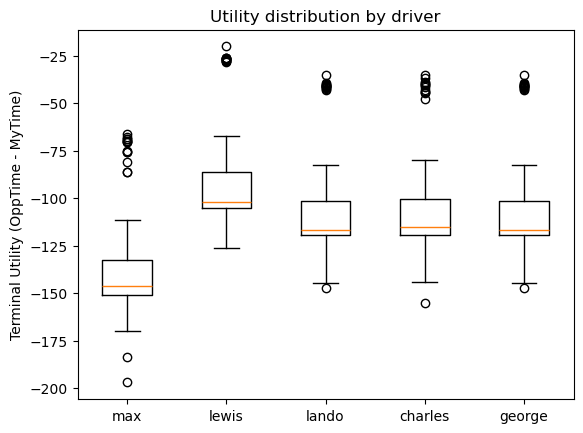

In [17]:
# Cell 5 — Figure 1: Utility distribution by driver (boxplot)
plt.figure()
order = drivers  # keep a consistent order
data = [df[df["driver"] == d]["utility"].dropna().values for d in order]
plt.boxplot(data, labels=order)
plt.ylabel("Terminal Utility (OppTime - MyTime)")
plt.title("Utility distribution by driver")
plt.show()

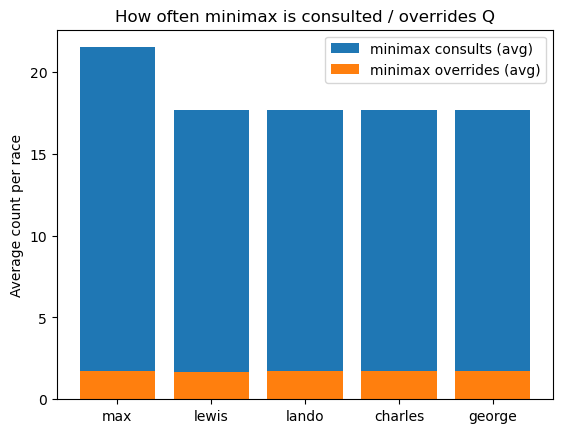

In [18]:
# Cell 6 — Figure 2: Minimax consults vs overrides
plt.figure()
g = df.groupby("driver")[["mm_consults", "mm_overrides"]].mean().reindex(drivers)
plt.bar(g.index, g["mm_consults"], label="minimax consults (avg)")
plt.bar(g.index, g["mm_overrides"], label="minimax overrides (avg)")
plt.ylabel("Average count per race")
plt.title("How often minimax is consulted / overrides Q")
plt.legend()
plt.show()

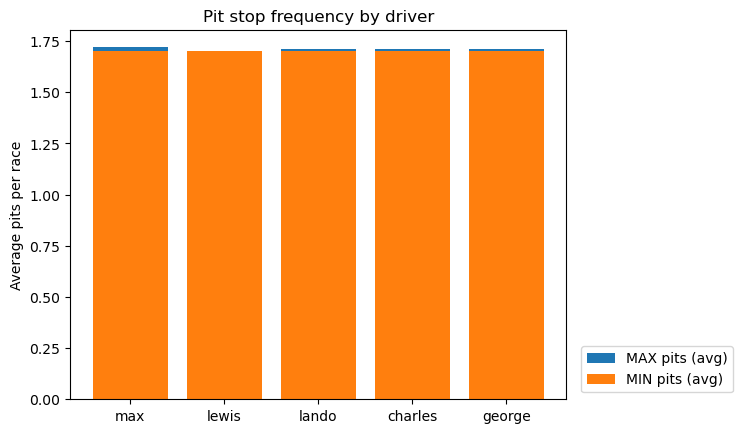

In [27]:
# Cell 7 — Figure 3: Pit stops per race (MAX vs MIN)
plt.figure()
g = df.groupby("driver")[["pits_max", "pits_min"]].mean().reindex(drivers)
plt.bar(g.index, g["pits_max"], label="MAX pits (avg)")
plt.bar(g.index, g["pits_min"], label="MIN pits (avg)")
plt.ylabel("Average pits per race")
plt.title("Pit stop frequency by driver")
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0))
plt.show()